# **Clustering on Student Performance Dataset**
## AI 221 Assignment 07

Submitted by: **Pangilinan, Reignel Bernice** 2018-01460 \\


Dataset reference: \\
Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T.



In [ ]:
! pip install ucimlrepo

In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import time
import warnings
warnings.filterwarnings("ignore")


from ucimlrepo import fetch_ucirepo

# Fetch dataset
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features   # Features
y = student_performance.data.targets    # Targets

print("========== Student Performance Dataset Features ==========")
display(X)    # Display the features of the datase

print("========== Student Performance Dataset Targets ==========")
display(y)    # Display the targets of the dataset

print(f"There are {X.shape[1]} features and {X.shape[0]} instances within the dataset.")

========== Student Performance Dataset Features ==========


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,yes,no,5,4,2,1,2,5,4
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,no,4,3,4,1,1,1,4
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,no,no,1,1,1,1,1,5,6
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,yes,no,2,4,5,3,4,2,6


========== Student Performance Dataset Targets ==========


,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13
...,...,...,...
644,10,11,10
645,15,15,16
646,11,12,9
647,10,10,10


There are 30 features and 649 instances within the dataset.


## **Exploratory Data Analysis**

Based on the metavariables, all features are categorical. This means that we have to encode features that are categorical and scale those that are nominal.

In [ ]:
print(student_performance.variables)    # Display information on the datatype of features

          name     role         type      demographic  \
0       school  Feature  Categorical             None   
1          sex  Feature       Binary              Sex   
2          age  Feature      Integer              Age   
3      address  Feature  Categorical             None   
4      famsize  Feature  Categorical            Other   
5      Pstatus  Feature  Categorical            Other   
6         Medu  Feature      Integer  Education Level   
7         Fedu  Feature      Integer  Education Level   
8         Mjob  Feature  Categorical       Occupation   
9         Fjob  Feature  Categorical       Occupation   
10      reason  Feature  Categorical             None   
11    guardian  Feature  Categorical             None   
12  traveltime  Feature      Integer             None   
13   studytime  Feature      Integer             None   
14    failures  Feature      Integer             None   
15   schoolsup  Feature       Binary             None   
16      famsup  Feature       B

After encoding the features, we can generate the correlation matrix. From this, we can identify which features are somewhat related to which.

========== Student Performance Dataset Features (Encoded) ==========


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,yes,no,5,4,2,1,2,5,4
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,no,4,3,4,1,1,1,4
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,no,no,1,1,1,1,1,5,6
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,yes,no,2,4,5,3,4,2,6


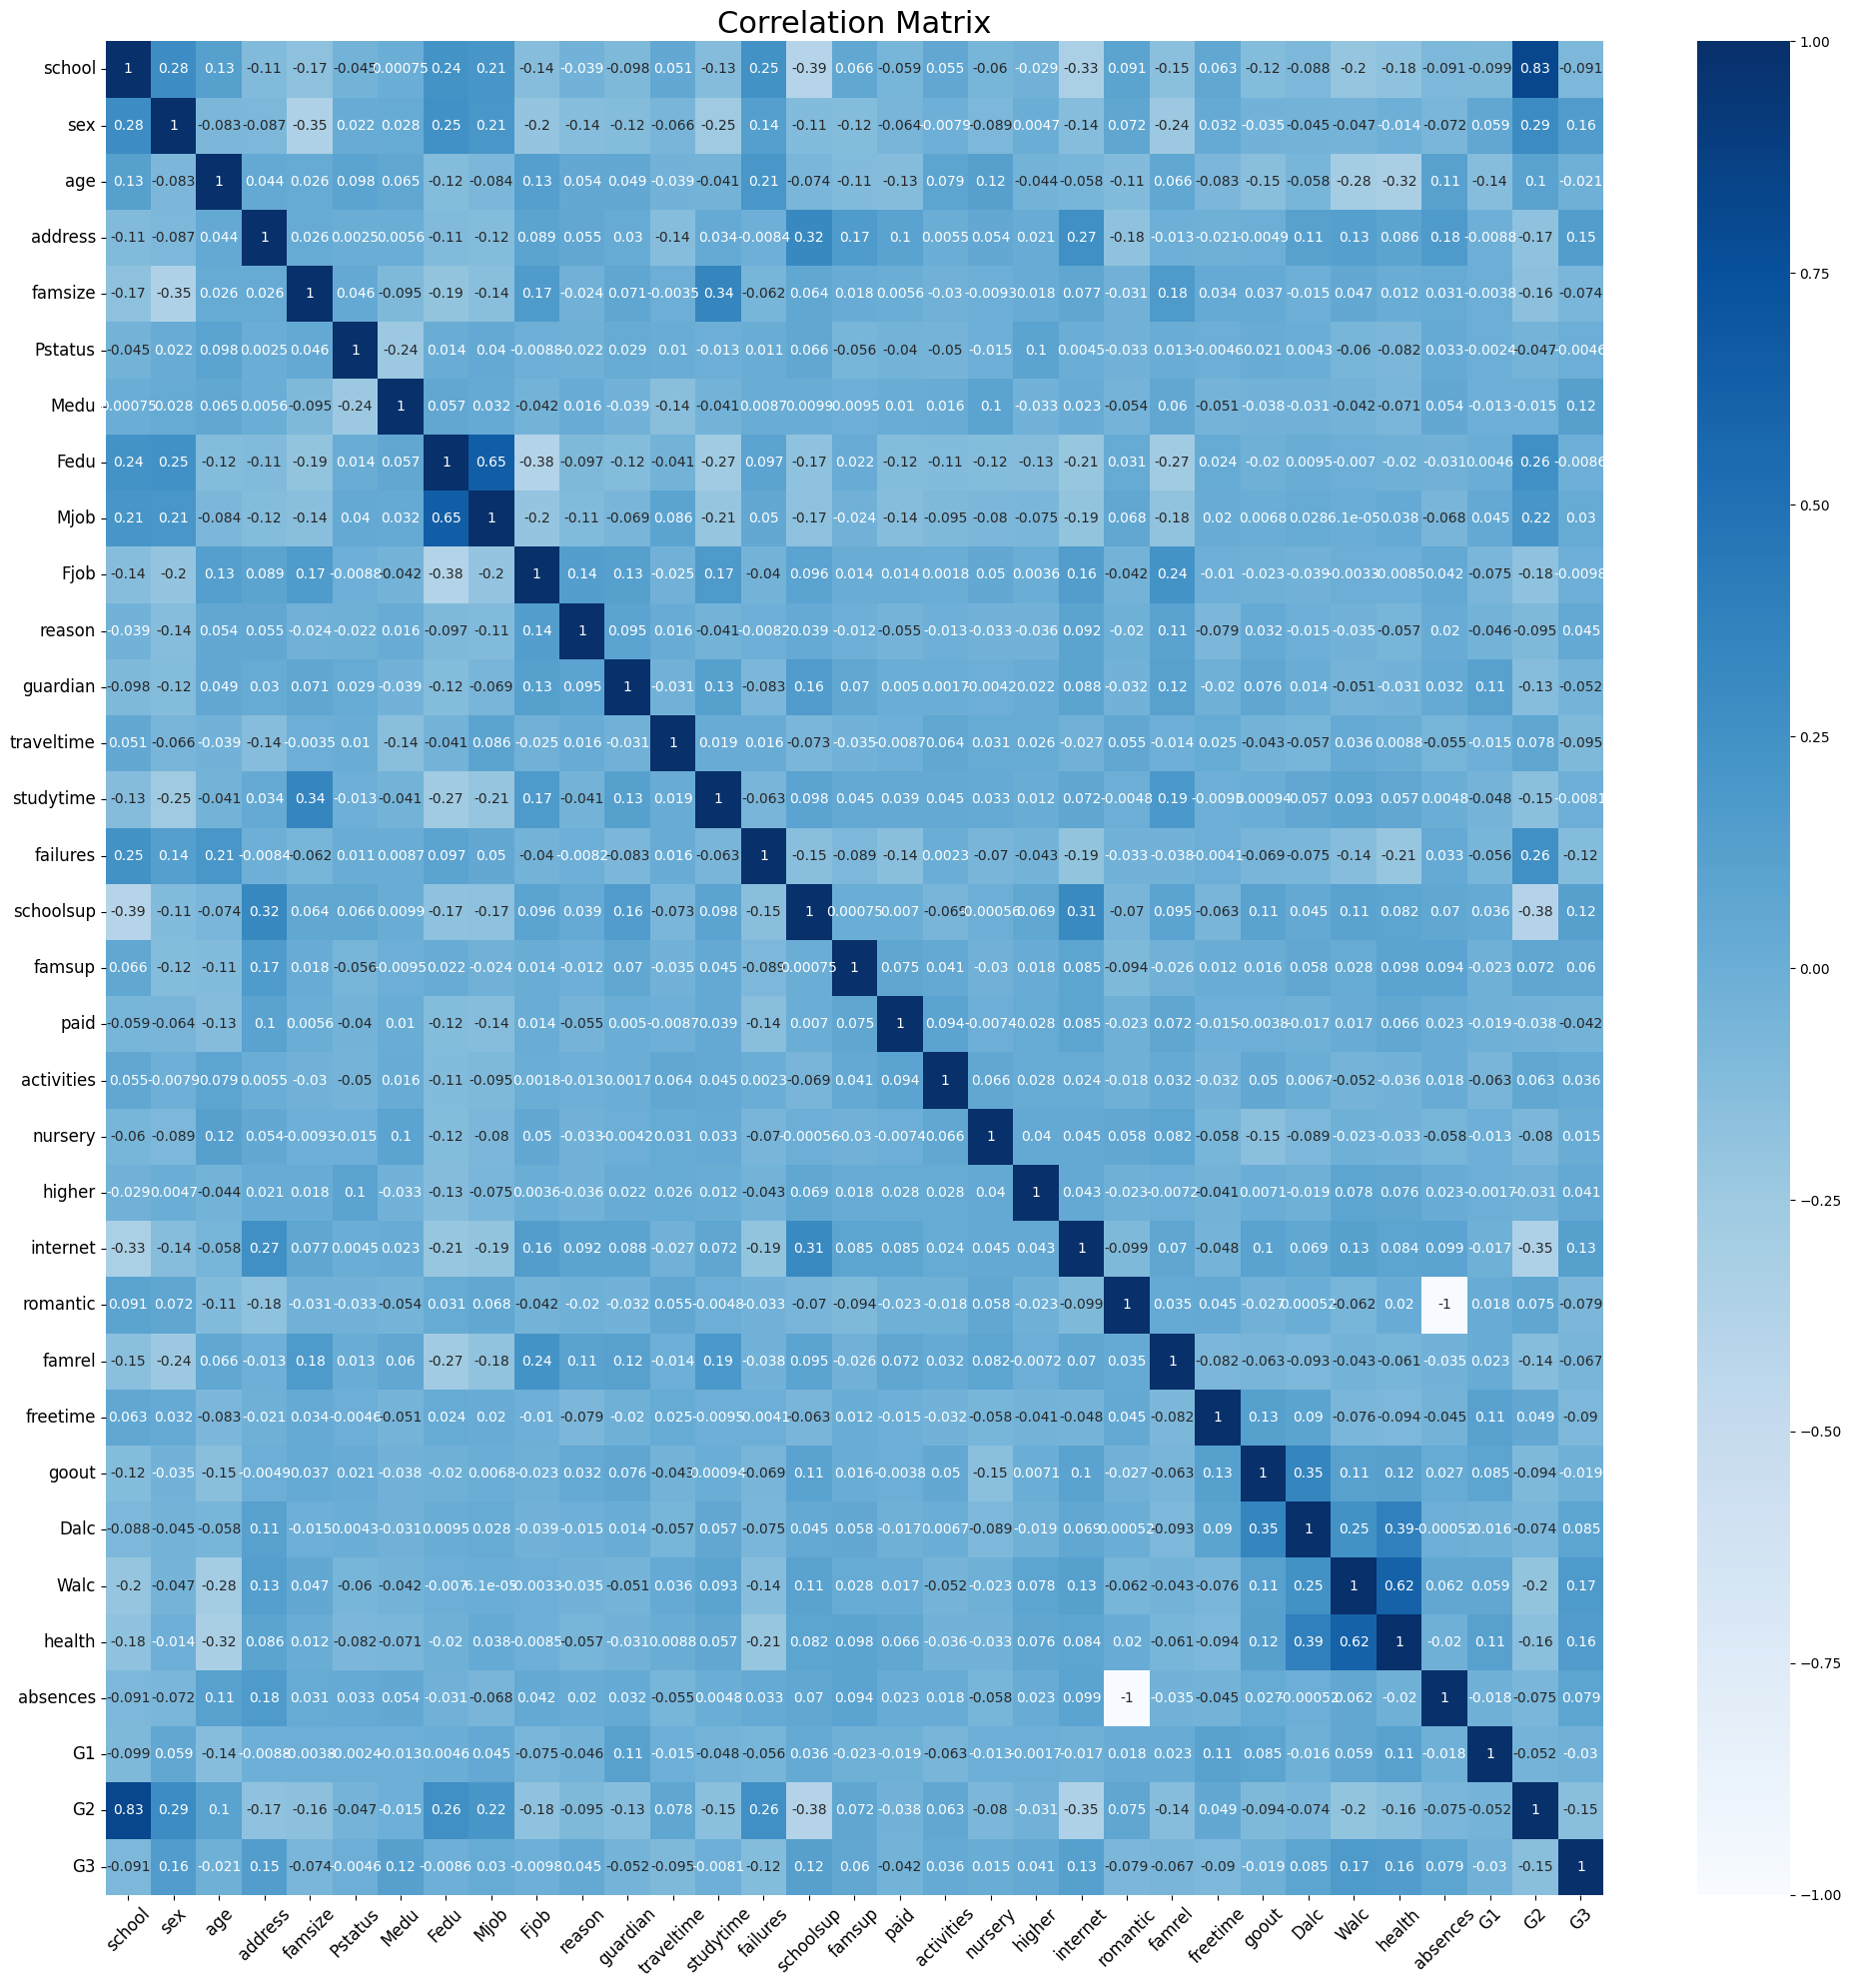

========== Highly-correlated features ==========
school and schoolsup: -0.39
school and internet: -0.33
school and G2: 0.83
sex and famsize: -0.35
age and health: -0.32
address and schoolsup: 0.32
famsize and studytime: 0.34
Fedu and Mjob: 0.65
Fedu and Fjob: -0.38
schoolsup and internet: 0.31
schoolsup and G2: -0.38
internet and G2: -0.35
romantic and absences: -1.00
goout and Dalc: 0.35
Dalc and health: 0.39
Walc and health: 0.62

Features with high correlation:
health
Fedu
studytime
Fjob
internet
romantic
Walc
famsize
school
goout
sex
schoolsup
absences
Dalc
Mjob
address
age
G2


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data = pd.concat([X, y], axis = 1)
## Encode the categorical labels within the dataset
encoder = OneHotEncoder(sparse_output = False)
scaler = StandardScaler()

features = data.columns.to_list()   # Get the features of the dataset

for feature in features:    # Encode only those whose datatype is object, integers will be scaled
  if data[feature].dtype == object:
    data[feature] = encoder.fit_transform(data[[feature]])
  elif data[feature].dtype == int:
    data[feature] = value = scaler.fit_transform(data[[feature]])

## Display the encoded dataset
print("========== Student Performance Dataset Features (Encoded) ==========")
display(X)

## Generate and display the correlation marix for the dataset
data = data.copy()
corr_matrix = data.corr()

plt.figure(figsize = (20, 20))    # Plot the correlation matrix
sns.heatmap(corr_matrix, annot = True, annot_kws = {"size": 10}, cmap = plt.cm.Blues)  # Customize the plot
plt.title("Correlation Matrix", fontsize = 22)
plt.xticks(rotation = 45, fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout()
plt.show()

## Filter the features with high correlation
threshold = 0.30

highly_correlated_features = []   # Initialize an empty list of highly-correlated features
for i in range(len(corr_matrix.columns)):   # Iterate over each value in the correlation matrix
  for j in range(i + 1, len(corr_matrix.columns)):
    if abs(corr_matrix.iloc[i, j]) > threshold:    # Append these to the list if value is beyond the threshold
      highly_correlated_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if not highly_correlated_features:    # If there are no highly-correlated values, print this
  print("No highly-correlated features found.")

else:
  print("========== Highly-correlated features ==========")    # Print and plot the features with high correlation
  for feature1, feature2, correlation in highly_correlated_features:
    print(f"{feature1} and {feature2}: {correlation:.2f}")

# Get the features with high correlation
column_names = []   # Initialize empty list of column names of highly-correlated features
for feature1, feature2, correlation in highly_correlated_features:
  column_names.append(feature1)   # Add them to the empty list
  column_names.append(feature2)

column_names = list(set(column_names))   # Remove duplicates
print("\nFeatures with high correlation:")    # Display the list of features with high correlation
for column in column_names:
  print(column)

## **Clustering**

**KMeans Clustering**

Perform KMeans clustering on the dataset and obtain a plot of the number of clusters and the inertia and silhouette scores. We can apply the elbow method ti the K v. inertia plot to determine the best number of of clusters K. Alternatively, we can look at the silhouette scores of varying K and identify which K has the highest silhouette score. Moreover, we can do PCA on the dataset as well as the centroids to visualize how the number of clusters affect the clustering using KMeans. We see from the results that having more than 2 clusters look confusing (eyeballing only)

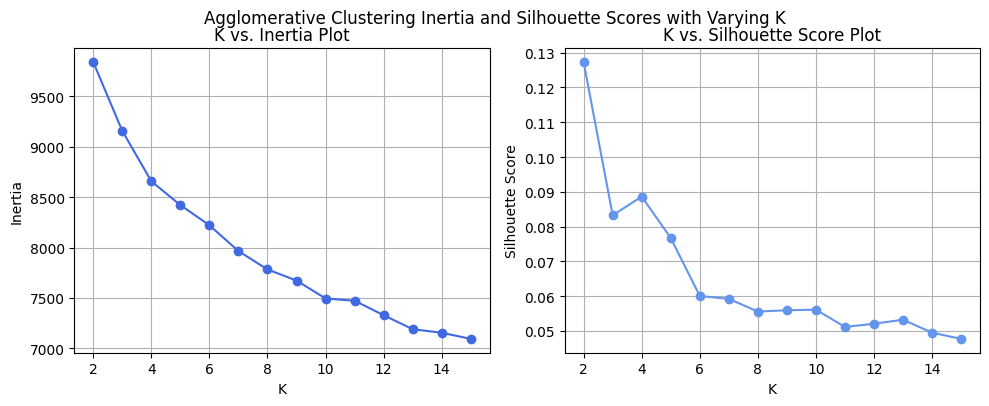

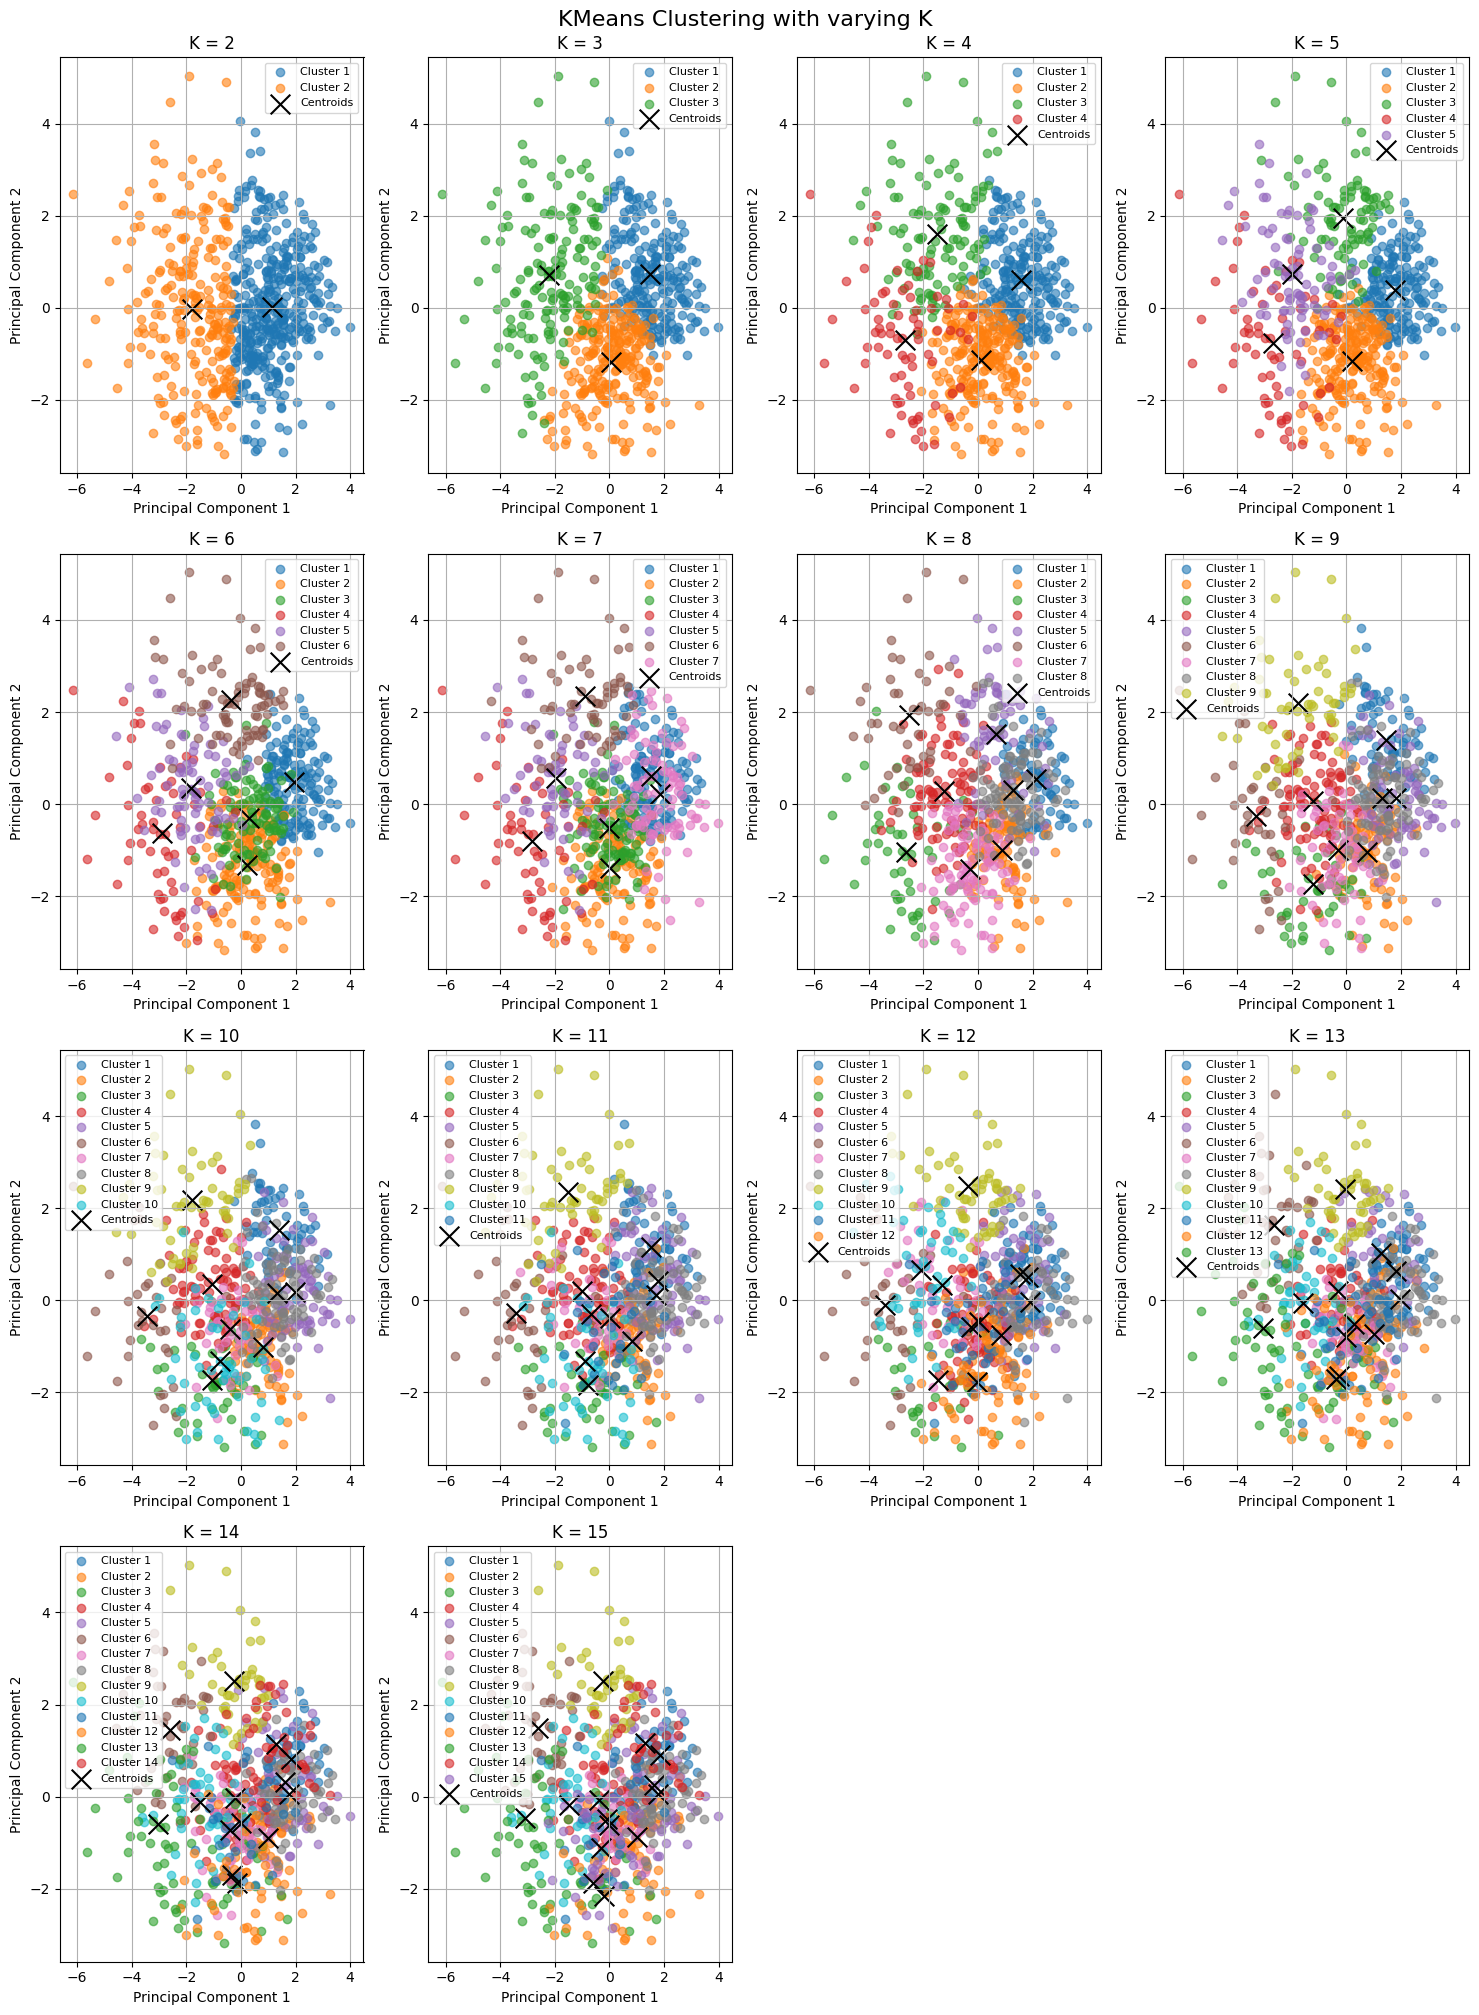

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Perform KMeans clustering, varying the number of clusters K
X = data.drop("G3", axis = 1)
clusters = np.arange(2, 15 + 1)   # Set the number of clusters to test

inertia_scores = []   # Initialize empty list where we can store the scores, labels, and centroids
silhouette_scores = []
centroids = []

for K in clusters:    # Perform KMeans clustering, varying the number of clusters K
  kmeans = KMeans(n_clusters = K, random_state = 0)   # Initialize K means clustering
  kmeans.fit(X)    # Fit the model
  inertia_scores.append(kmeans.inertia_) # Compute for the inertia --> sum of squared distances to cluster centers and append to the list
  silhouette_scores.append(silhouette_score(X, labels = kmeans.predict(X)))  # Compute for the silhouette scores and append to the list
  centroids.append(kmeans.cluster_centers_) # Append the centroids to the empty list

plt.figure(figsize = (10, 4))   # Initialize figure size
plt.subplot(1, 2, 1)    # Create subplots to show the two subplots side by side
plt.plot(clusters, inertia_scores, marker = "o", color = "royalblue") # Plot the number of clusters vs. inertia
plt.xlabel("K")   # Set axis titles
plt.ylabel("Inertia")
plt.title("K vs. Inertia Plot")   # Set plot titles
plt.grid()    # Add a grid

plt.subplot(1, 2, 2)
plt.plot(clusters, silhouette_scores, marker = "o", color = "cornflowerblue") # Plot the number of clusters vs. silhouette score
plt.xlabel("K")   # Seth axis titles
plt.ylabel("Silhouette Score")    # Set plot titles
plt.title("K vs. Silhouette Score Plot")
plt.grid()    # Add a grid

plt.tight_layout()    # Adjust the layout of the subplots
plt.suptitle("Agglomerative Clustering Inertia and Silhouette Scores with Varying K", y = 1.005)
plt.show()


### Perform PCA on the datset for visualization of the clusters with varying K
X = X.copy()
pca = PCA(n_components = 2)   # Perform PCA on the dataset with 2 principal components
X_pca = pca.fit_transform(X)

### Create a plot with subplots of the clusters with the centroids
n_rows_cols = 4   # Specify number of rows and columns (make it square)

# Initialize the figure
fig, axes = plt.subplots(nrows = len(clusters) // n_rows_cols + 1, ncols = n_rows_cols, figsize = (15, 5*(len(clusters) // n_rows_cols + 1)))

for i, K in enumerate(clusters):    # Iterate over all number of clusters
  kmeans = KMeans(n_clusters = K, random_state = 0)   # Do KMeans clustering
  kmeans.fit(X)   # Fit the model

  centroids_pca = pca.transform(kmeans.cluster_centers_)    # Perform PCA on the centroids for visualization

  row = i // n_rows_cols    # Create plot wiht 4x4 subplots
  col = i % n_rows_cols
  ax = axes[row, col]   # Indices of the rows and columns

  for j in range(K):    # Create scatterplots of the results with varying number of clusters
    ax.scatter(X_pca[kmeans.labels_ == j, 0], X_pca[kmeans.labels_ == j, 1], label = f"Cluster {j + 1}", alpha = 0.6)
  ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker = "x", s = 200, c = "k", label = "Centroids")   # Plot the centroids
  ax.set_xlabel("Principal Component 1")    # Set the axis titles of each subplot
  ax.set_ylabel("Principal Component 2")
  ax.set_title(f"K = {K}")   # Set the plot title of each subplot
  ax.grid()   # Add a grid
  ax.legend(loc = "best", fontsize = 8)   # Include a legend, adjusting the fontsize

plt.tight_layout()    # Adjust the layout of the entire plot
for i in range(len(clusters), len(axes.flat)):    # Delete subplots that are empty
  fig.delaxes(axes.flat[i])

plt.suptitle("KMeans Clustering with varying K", y = 1.005, fontsize = 16)    # Set the plot title for the entire figure
plt.show()


Getting the best value for K, we can compare how each feature is distributed within each cluster to give us a better idea how each cluster is grouped.

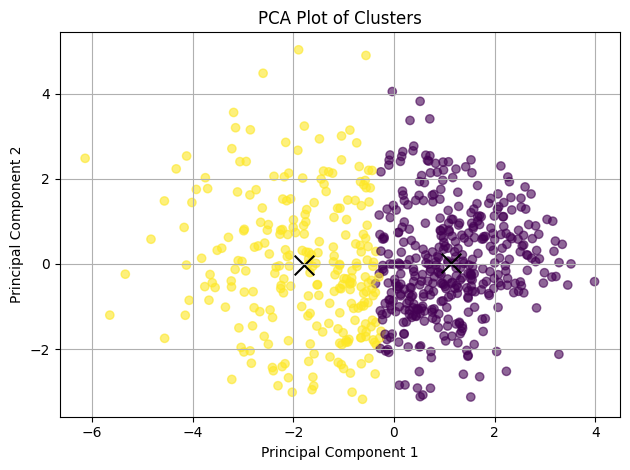

Silhouette Score with K = 2: 0.12727229324504763


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.498446,0.786432,0.650754,-0.206835,0.218593,0.698492,0.130653,0.328397,0.287958,0.118090,...,0.170854,0.051558,-0.138155,-0.174489,-0.268950,-0.265494,0.339196,-0.105033,0.527736,-0.114040
1,-0.790364,0.438247,0.494024,0.327970,0.438247,0.713147,0.111554,-0.520726,-0.456603,0.350598,...,0.330677,-0.081753,0.219066,0.276680,0.426462,0.420983,0.414343,0.166546,-0.836808,0.180828


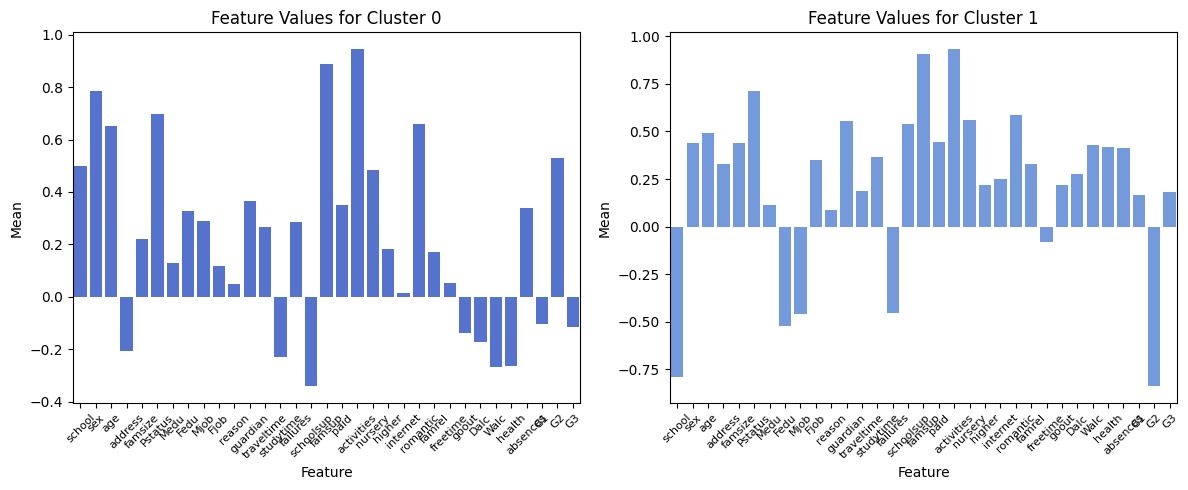

In [ ]:
X = X.copy()

## Perform KMeans clustering
for i in range(len(silhouette_scores)):   # Find the number of clusters where the silhouette score is the highest
  index = np.where(np.max(silhouette_scores))
K_best = int(clusters[index])

kmeans = KMeans(n_clusters = K_best, random_state = 0)   # Initialize a KMeans model using the best K value
data["Cluster"] = kmeans.fit_predict(X)

## Perform PCA on the data for visualization
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = data["Cluster"], alpha = 0.6)   # Create a scatter plot of the clusters
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0], pca.transform(kmeans.cluster_centers_)[:, 1], marker = "x",
            s = 200, c = "k", label = "Centroids")   # Plot the centroids
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Plot of Clusters")
plt.tight_layout()
plt.grid()
plt.show()

## Evaluate the silhouette score using the best K
sil_score = silhouette_score(X, data["Cluster"])
print(f"Silhouette Score with K = {K_best}: {sil_score}")

## Compare clusters based on features
df = data.groupby("Cluster").mean()   # Based on the mean of the features per cluster, we can get an idea of how they are grouped
display(df)
df_transposed = df.T    # Transpose dataframe for plotting
df_transposed.columns = ["Cluster 0", "Cluster 1"]    # Column titles of the tranposed dataframe
df_transposed = df_transposed.reset_index().rename(columns = {"index": "Feature"})

## Plot the means as bar plots for comparison
plt.figure(figsize = (12, 5))   # Initialize the figure size with 2 subplots

plt.subplot(1, 2, 1)    # Plot for Cluster 0
sns.barplot(x = "Feature", y = "Cluster 0", data = df_transposed, color = "royalblue")
plt.xticks(rotation = 45, fontsize = 8)
plt.title("Feature Values for Cluster 0")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.subplot(1, 2, 2)    # Plot for Cluster 1
sns.barplot(x = "Feature", y = "Cluster 1", data = df_transposed, color = "cornflowerblue")
plt.xticks(rotation = 45, fontsize = 8)
plt.title("Feature Values for Cluster 1")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.tight_layout()
plt.show()

## **Conclusions**

Based on the results using KMeans clustering using the best K value determined by looking at the K with the maximum silhouette score, we may conclude the following:

**Cluster 0** \\
Positive Values:
Features like school, sex, famsize, studytime, activities have higher mean values. This suggests that this cluster may have students from larger families, more engaged in extracurricular activities, and have higher study time.

Negative Values:
Features like failures, absences, and G3 (final grade) have lower mean values. This indicates that students in this cluster may have fewer failures, lower absences, and are potentially higher academic performance.

Possible Interpretation:
Cluster 0 may represent students who are academically stronger, more engaged in school activities, and have supportive family backgrounds.

**Cluster 1** \\
Positive Values: Features like studytime, internet access, and activities show higher means, suggesting that these students have access to the internet and engage in more extracurriculars.

Negative Values:
Features like school, failures, and absences have lower values, which could indicate lower school engagement, more failures, and higher absenteeism.

Possible Interpretation:
Cluster 1 may represent students who struggle academically, have higher absences, and potentially less engagement with their studies despite access to resources like the internet.

**Key Takeaways** \\
Cluster 0 might be high-achievers, with strong academic performance and engagement. They can thus be encouraged to maintain their performance and engagement. On the other hand, Cluster 1 might be struggling students, with lower grades and attendance issues. They may benefit from academic support or attendance monitoring.

**Other notes:** \\
The results here also show that a student's socioeconomic status such as their parents' job and access to internet affects how they perform well in school. For example, the means of the educational background and job of parents in Cluster 0 are higher than those in Cluster 1. Cluster 1 even has a negative value for Fedu. Moreover, access to internet is higher in Cluster 0 than in Cluster 1, this tells us that indeed access to the internet affects a student's performance greatly. While these results should not be taken as a causation, it just tells us that even clustering models suggest what we have taken as the truth: that those who are privileged enough to have the necessary resources (financial, and otherwise) for school are those who generally do well due to the opportunities that are available to them.